<div style="
    background-image: url('https://images.unsplash.com/photo-1447933601403-0c6688de566e?w=1200');
    background-size: cover;
    background-position: center;
    padding: 60px 30px;
    border-radius: 15px;
    text-align: center;
    position: relative;
">
    <div style="
        background: rgba(62, 39, 35, 0.75);
        padding: 30px;
        border-radius: 10px;
        display: inline-block;
    ">
        <h1 style="color: #FFF8E1; font-size: 40px; margin: 0;">
            ☕ Coffee Quality &amp; Pricing Benchmark ☕
        </h1>
        <p style="color: #FFECB3; margin-top: 10px; font-size: 16px; text-align: center; ">
                                 From Bean to Price — A Data-Driven Journey
        </p>
    </div>
</div>

In [1]:
'''
The imports up top? Yeah, they're a mess.

I've been testing this thing for way too long, and somewhere in all that chaos I imported stuff I never ended up using.
Never got around to cleaning it up. Maybe next update. Maybe.

If you're wondering why something's imported — past me was experimenting, future me forgot. Sorry about that.

Parsa
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


from sklearn.linear_model import LinearRegression



from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("/kaggle/input/datasets/razanihababdellatif/coffee-quality-and-pricing-benchmark/coffee_value_benchmark.csv")
data

,record_id,lot_id,harvest_season,harvest_calendar_year,harvest_month,country_of_origin,farm_type,farm_size_hectares,tree_age_years,altitude_mean_meters,...,lot_size_kg,roast_level,acidity_score,sweetness_score,body_score,aroma_score,flavor_score,coffee_quality_score,quality_grade,price_usd_per_kg
0,REC-0000001,LOT-0032936,2020/21,2020,10,Vietnam,Smallholder,0.58,28.0,1961.0,...,26433.0,Medium,7.95,7.30,8.45,7.35,7.37,78.01,Very Good,2.43
1,REC-0000002,LOT-0030952,2021/22,2022,1,Honduras,Smallholder,1.12,2.0,1257.0,...,25446.0,Medium,7.62,8.17,7.45,7.80,6.88,75.62,Good,4.06
2,REC-0000003,LOT-0018572,2020/21,2020,11,Vietnam,Cooperative,13.82,5.0,557.0,...,15707.0,Medium,8.47,8.83,8.13,7.70,8.10,72.41,Commercial,4.26
3,REC-0000004,LOT-0005318,2021/22,2021,10,Vietnam,Cooperative,9.96,22.0,652.0,...,2879.0,Medium,7.54,8.12,8.21,7.77,7.13,75.67,Good,3.60
4,REC-0000005,LOT-0006317,2021/22,2021,7,Brazil,Smallholder,1.90,11.0,971.0,...,9561.0,Medium,6.70,8.08,8.68,7.38,7.16,73.77,Good,4.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35695,REC-0035696,LOT-0016851,2021/22,2021,10,Vietnam,Estate,12.56,11.0,589.0,...,1814.0,Medium,7.18,6.85,8.21,6.91,6.77,67.94,Commercial,4.61
35696,REC-0035697,LOT-0006266,2023/24,2023,10,Ethiopia,Cooperative,6.86,4.0,1572.0,...,29945.0,Dark,7.03,7.90,9.21,7.55,7.60,77.28,Very Good,5.46
35697,REC-0035698,LOT-0011285,2021/22,2021,11,Vietnam,Smallholder,1.08,39.0,366.0,...,29282.0,Dark,6.71,6.18,8.05,7.87,6.79,72.63,Commercial,3.32
35698,REC-0035699,LOT-0000861,2019/20,2020,1,Vietnam,Cooperative,7.01,7.0,509.0,...,30928.0,Dark,6.20,7.36,7.72,6.37,6.26,69.82,Commercial,3.34


# EDA 

In [3]:
# Check dataset dimensions
print(f"Shape of dataset: {data.shape}")

# Check data types and non-null counts
print("\n--- Data Info ---")
data.info()

Shape of dataset: (35700, 36)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35700 entries, 0 to 35699
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               35700 non-null  object 
 1   lot_id                  35700 non-null  object 
 2   harvest_season          35700 non-null  object 
 3   harvest_calendar_year   35700 non-null  int64  
 4   harvest_month           35700 non-null  int64  
 5   country_of_origin       35700 non-null  object 
 6   farm_type               35700 non-null  object 
 7   farm_size_hectares      35700 non-null  float64
 8   tree_age_years          35700 non-null  float64
 9   altitude_mean_meters    35700 non-null  float64
 10  species                 35700 non-null  object 
 11  avg_temp_c              35700 non-null  float64
 12  avg_annual_rainfall_mm  33881 non-null  float64
 13  humidity_pct            33418 non-null  fl

Columns with Missing Values (%):
certification             60.848739
humidity_pct               6.392157
avg_annual_rainfall_mm     5.095238
bean_density_g_ml          4.571429
moisture_pct               4.515406
dtype: float64


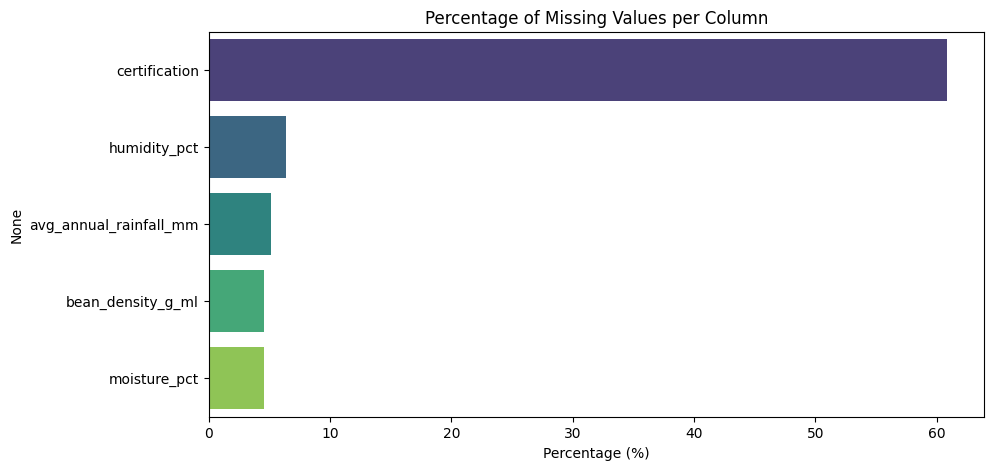

In [4]:
# Calculate percentage of missing values per column
missing_values = data.isnull().sum() / len(data) * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_values.empty:
    print("Columns with Missing Values (%):")
    print(missing_values)
    
    # Plot missing values
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_values.values, y=missing_values.index,legend=False,palette='viridis', hue=missing_values.index)
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Percentage (%)')
    plt.show()
else:
    print("No missing values found! The dataset is clean.")

In [5]:
# Descriptive statistics for numerical columns
display(data.describe().T)

# Descriptive statistics for categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns
display(data[categorical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
harvest_calendar_year,35700.0,2021.470308,1.282059,2019.000,2021.000,2021.000,2022.00,2024.000
harvest_month,35700.0,8.091401,3.230757,1.000,6.000,9.000,11.00,12.000
farm_size_hectares,35700.0,16.588095,37.377621,0.350,1.570,2.750,14.99,920.260
tree_age_years,35700.0,15.140364,8.013493,2.000,9.000,14.000,19.00,50.000
altitude_mean_meters,35700.0,1145.550896,531.533991,150.000,692.000,1071.000,1616.00,2726.000
avg_temp_c,35700.0,18.182387,4.432564,7.100,14.100,19.000,22.00,27.000
avg_annual_rainfall_mm,33881.0,1884.958886,530.862432,327.000,1453.000,1883.000,2303.00,3345.000
humidity_pct,33418.0,74.532743,6.099831,55.900,69.800,74.200,79.40,93.300
drying_duration_days,35700.0,14.277216,5.039598,2.000,11.000,14.600,17.80,29.200
storage_months,35700.0,3.996723,2.001782,0.000,3.000,4.000,5.00,15.000


,count,unique,top,freq
record_id,35700,35700,REC-0035700,1
lot_id,35700,35000,LOT-0025302,3
harvest_season,35700,5,2021/22,10747
country_of_origin,35700,7,Brazil,11510
farm_type,35700,3,Smallholder,19758
species,35700,2,Arabica,23173
processing_method,35700,4,Washed,17884
drying_method,35700,3,Patio,18886
storage_conditions,35700,2,Basic,22140
traceability_level,35700,5,Country,11064


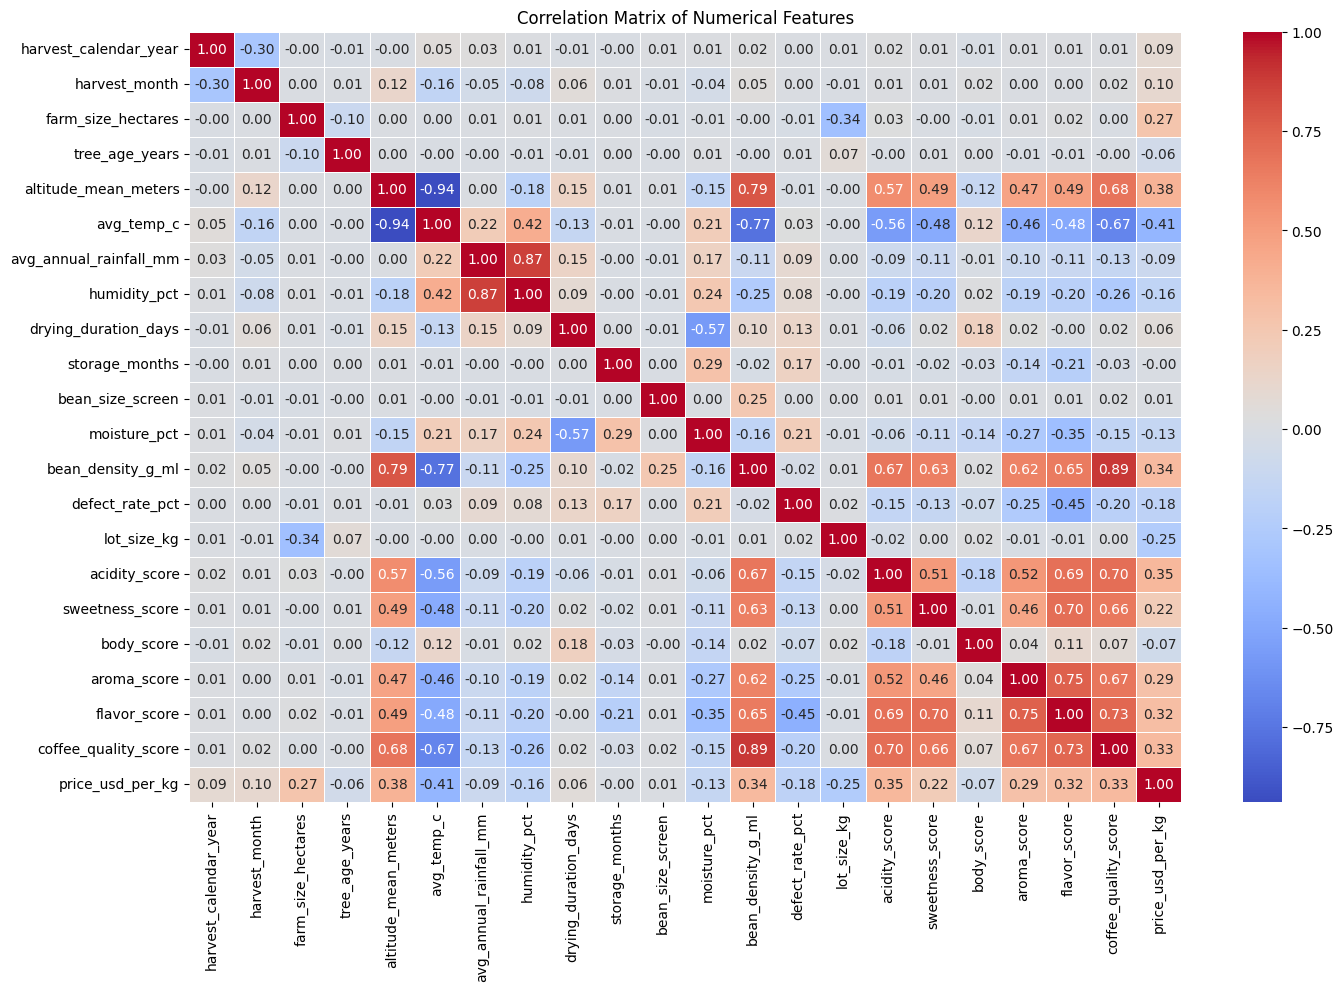


Top Correlations with Coffee Quality Score:
coffee_quality_score    1.000000
bean_density_g_ml       0.889589
flavor_score            0.729639
acidity_score           0.699446
altitude_mean_meters    0.681905
aroma_score             0.669724
sweetness_score         0.659483
price_usd_per_kg        0.334930
body_score              0.066674
drying_duration_days    0.019911
Name: coffee_quality_score, dtype: float64


In [6]:
# Select only numerical columns
numeric_df = data.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Top correlations with the quality score
if 'coffee_quality_score' in corr_matrix.columns:
    print("\nTop Correlations with Coffee Quality Score:")
    print(corr_matrix['coffee_quality_score'].sort_values(ascending=False).head(10))

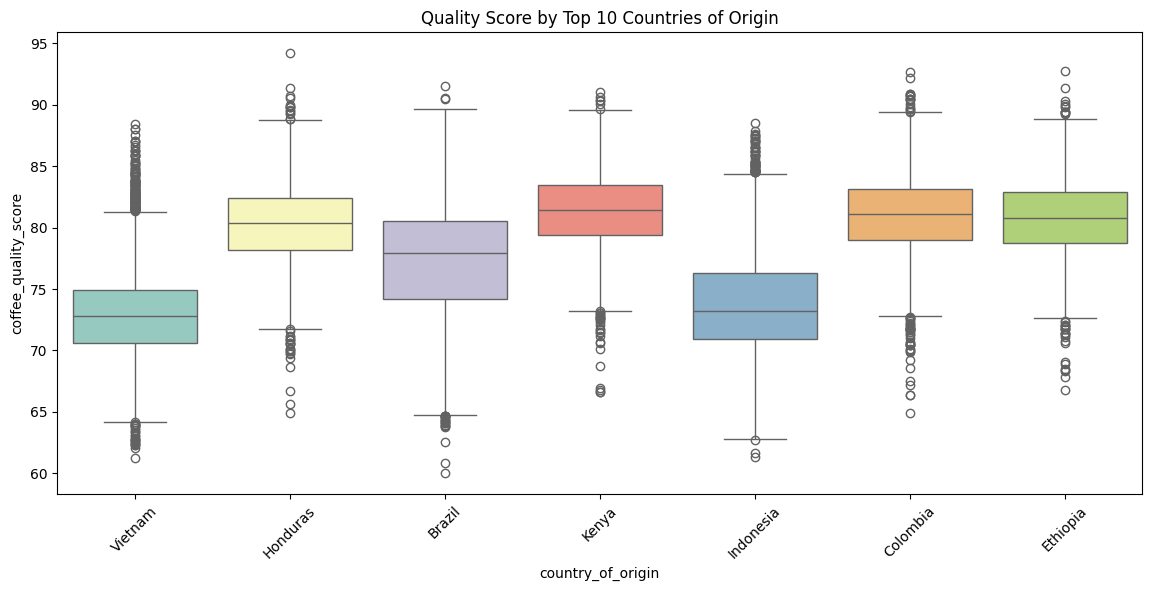

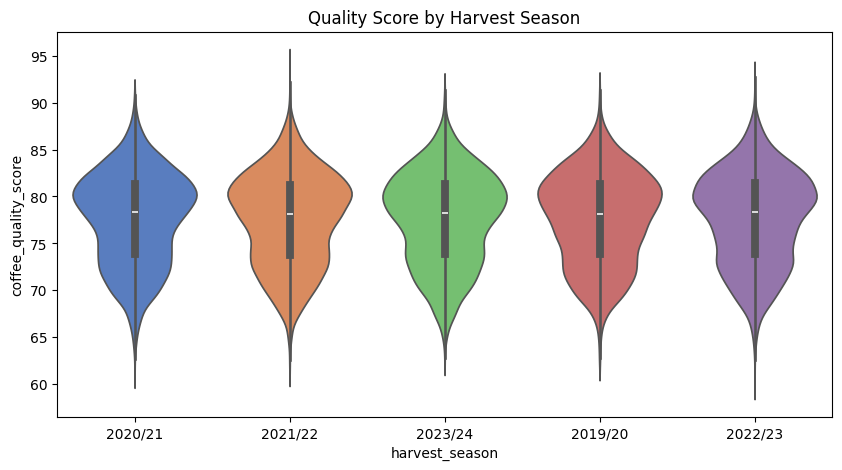

In [7]:
# Impact of Country of Origin on Quality Score
plt.figure(figsize=(14, 6))
top_countries = data['country_of_origin'].value_counts().head(10).index
sns.boxplot(data=data[data['country_of_origin'].isin(top_countries)], 
            x='country_of_origin', y='coffee_quality_score', palette='Set3',legend=False,hue='country_of_origin')
plt.xticks(rotation=45)
plt.title('Quality Score by Top 10 Countries of Origin')
plt.show()

# Impact of Harvest Season
plt.figure(figsize=(10, 5))
sns.violinplot(data=data, x='harvest_season', y='coffee_quality_score', palette='muted',legend=False,hue='harvest_season')
plt.title('Quality Score by Harvest Season')
plt.show()

# Deal with missing value

# 📊 Missing Values — Quick Status Analysis

| Column | Missing (%) | Data Type | Status |
|--------|-------------|-----------|--------|
| `certification` | **60.85%** | Categorical | 🚨 Critical |
| `humidity_pct` | 6.39% | Numerical | ⚠️ Low |
| `avg_annual_rainfall_mm` | 5.10% | Numerical | ⚠️ Low |
| `bean_density_g_ml` | 4.57% | Numerical | ⚠️ Low |
| `moisture_pct` | 4.52% | Numerical | ⚠️ Low |

In [8]:
data.drop(columns=['certification'], inplace=True)

numeric_cols = data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    data.fillna({col: data[col].median()}, inplace=True)

print("Missing values after imputation:")
print(data.isnull().sum())
print(f"\n New shape of dataset after imputation: {data.shape}")

Missing values after imputation:
record_id                 0
lot_id                    0
harvest_season            0
harvest_calendar_year     0
harvest_month             0
country_of_origin         0
farm_type                 0
farm_size_hectares        0
tree_age_years            0
altitude_mean_meters      0
species                   0
avg_temp_c                0
avg_annual_rainfall_mm    0
humidity_pct              0
processing_method         0
drying_method             0
drying_duration_days      0
storage_months            0
storage_conditions        0
bean_size_screen          0
moisture_pct              0
bean_density_g_ml         0
defect_rate_pct           0
traceability_level        0
intended_buyer_segment    0
lot_size_kg               0
roast_level               0
acidity_score             0
sweetness_score           0
body_score                0
aroma_score               0
flavor_score              0
coffee_quality_score      0
quality_grade             0
price_usd_per_k

# Creat model

In [9]:
# Target variable
TARGET = 'coffee_quality_score'

# Columns to drop (IDs + Leakage + High-missing)
DROP_COLS = [
    'record_id',              # ID
    'lot_id',                 # ID          
    'quality_grade',          # LEAKAGE (derived from target)
    'price_usd_per_kg',       # LEAKAGE (correlated with target)
    TARGET                    # Target itself
]

# Features (X) and Target (y)
X = data.drop(columns=DROP_COLS)
y = data[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

Features shape: (35700, 30)
Target shape:   (35700,)

Feature columns:
['harvest_season', 'harvest_calendar_year', 'harvest_month', 'country_of_origin', 'farm_type', 'farm_size_hectares', 'tree_age_years', 'altitude_mean_meters', 'species', 'avg_temp_c', 'avg_annual_rainfall_mm', 'humidity_pct', 'processing_method', 'drying_method', 'drying_duration_days', 'storage_months', 'storage_conditions', 'bean_size_screen', 'moisture_pct', 'bean_density_g_ml', 'defect_rate_pct', 'traceability_level', 'intended_buyer_segment', 'lot_size_kg', 'roast_level', 'acidity_score', 'sweetness_score', 'body_score', 'aroma_score', 'flavor_score']


In [10]:
# Split FIRST — before imputation or encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 80% train, 20% test
    random_state=42,        # reproducibility
    shuffle=True
)

print(f"X_train: {X_train.shape}   |   X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}   |   y_test: {y_test.shape}")

X_train: (28560, 30)   |   X_test: (7140, 30)
y_train: (28560,)   |   y_test: (7140,)


In [11]:
# Separate numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Numerical columns (20):
['harvest_calendar_year', 'harvest_month', 'farm_size_hectares', 'tree_age_years', 'altitude_mean_meters', 'avg_temp_c', 'avg_annual_rainfall_mm', 'humidity_pct', 'drying_duration_days', 'storage_months', 'bean_size_screen', 'moisture_pct', 'bean_density_g_ml', 'defect_rate_pct', 'lot_size_kg', 'acidity_score', 'sweetness_score', 'body_score', 'aroma_score', 'flavor_score']

Categorical columns (10):
['harvest_season', 'country_of_origin', 'farm_type', 'species', 'processing_method', 'drying_method', 'storage_conditions', 'traceability_level', 'intended_buyer_segment', 'roast_level']


In [12]:
# Numerical pipeline: Impute with median + Scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute with mode + One-Hot Encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("✅ Preprocessor built successfully.")

✅ Preprocessor built successfully.


In [13]:
# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using parameters learned from train
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")

X_train_processed shape: (28560, 57)
X_test_processed shape:  (7140, 57)


In [14]:
# Get feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame (optional, but useful for inspection)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names, index=X_test.index)

print(f"Total features after encoding: {len(feature_names)}")
display(X_train_df.head())

Total features after encoding: 57


,num__harvest_calendar_year,num__harvest_month,num__farm_size_hectares,num__tree_age_years,num__altitude_mean_meters,num__avg_temp_c,num__avg_annual_rainfall_mm,num__humidity_pct,num__drying_duration_days,num__storage_months,...,cat__traceability_level_Country,cat__traceability_level_Farm,cat__traceability_level_Microlot,cat__traceability_level_Region,cat__intended_buyer_segment_Commodity,cat__intended_buyer_segment_Premium,cat__intended_buyer_segment_Specialty,cat__roast_level_Dark,cat__roast_level_Light,cat__roast_level_Medium
10927,1.192211,0.587643,-0.267417,0.352598,-1.823423,1.881275,2.059363,2.557073,2.248222,-0.000087,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
27704,-0.366335,0.278300,-0.387302,0.228102,-0.322511,0.212227,-1.238581,-0.049629,0.437024,1.497470,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
32564,-1.145607,-0.340385,-0.408758,-1.265844,-0.723130,0.482883,-0.172169,-0.726694,-0.160074,1.497470,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
17099,-1.145607,0.278300,-0.421095,-0.269880,-0.200256,0.189672,-0.704407,-1.319126,-0.319300,0.998284,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
34645,-0.366335,-0.959071,0.007488,-0.020889,-0.623446,0.573102,-0.526349,-0.049629,1.471994,0.998284,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [15]:
# Sanity checks
print("✅ Leakage Check:")
print(f"   Train rows: {X_train.shape[0]}")
print(f"   Test rows:  {X_test.shape[0]}")
print(f"   Sum:        {X_train.shape[0] + X_test.shape[0]} (should equal {X.shape[0]})")
print(f"\n   Any NaN in X_train_processed? {np.isnan(X_train_processed).any()}")
print(f"   Any NaN in X_test_processed?  {np.isnan(X_test_processed).any()}")
print(f"\n   Target mean (train): {y_train.mean():.3f}")
print(f"   Target mean (test):  {y_test.mean():.3f}  (should be close)")

✅ Leakage Check:
   Train rows: 28560
   Test rows:  7140
   Sum:        35700 (should equal 35700)

   Any NaN in X_train_processed? False
   Any NaN in X_test_processed?  False

   Target mean (train): 77.611
   Target mean (test):  77.567  (should be close)


##  Build a simpel model for test 

In [16]:
# Train model
model = LinearRegression()
model.fit(X_train_processed, y_train)

# Predict
y_pred = model.predict(X_test_processed)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 Baseline Model (Linear Regression)")
print(f"   RMSE: {rmse:.4f}")
print(f"   R²:   {r2:.4f}")

📊 Baseline Model (Linear Regression)
   RMSE: 1.7706
   R²:   0.8703


##  Build Model

In [17]:
# Three tree-based models to compare
MODELS = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        n_jobs=-1,
        random_state=42,
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        n_jobs=-1,
        random_state=42,
        verbosity=0,
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    ),
}

In [18]:
def evaluate(y_true, y_pred, label):
    """Return a dict of regression metrics for a set of predictions."""
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae":  mean_absolute_error(y_true, y_pred),
        "r2":   r2_score(y_true, y_pred),
    }

In [19]:
results = {}

for name, model in MODELS.items():
    start = time.time()
    model.fit(X_train_processed, y_train)
    elapsed = time.time() - start

    y_train_pred = model.predict(X_train_processed)
    y_test_pred  = model.predict(X_test_processed)

    results[name] = {
        "model":        model,
        "y_test_pred":  y_test_pred,
        "train":        evaluate(y_train, y_train_pred, "Train"),
        "test":         evaluate(y_test,  y_test_pred,  "Test"),
        "time":         elapsed,
    }

In [20]:
for name, r in results.items():
    print(f"\n{'─' * 55}")
    print(f"  {name}   (trained in {r['time']:.1f}s)")
    print(f"{'─' * 55}")
    for split in ("train", "test"):
        m = r[split]
        print(f"  {split:5s} | RMSE: {m['rmse']:.4f}  MAE: {m['mae']:.4f}  R²: {m['r2']:.4f}")


───────────────────────────────────────────────────────
  RandomForest   (trained in 29.0s)
───────────────────────────────────────────────────────
  train | RMSE: 0.8877  MAE: 0.7103  R²: 0.9674
  test  | RMSE: 1.7407  MAE: 1.3751  R²: 0.8747

───────────────────────────────────────────────────────
  XGBoost   (trained in 1.3s)
───────────────────────────────────────────────────────
  train | RMSE: 1.3888  MAE: 1.1002  R²: 0.9201
  test  | RMSE: 1.6720  MAE: 1.3254  R²: 0.8844

───────────────────────────────────────────────────────
  LightGBM   (trained in 0.9s)
───────────────────────────────────────────────────────
  train | RMSE: 1.4787  MAE: 1.1746  R²: 0.9095
  test  | RMSE: 1.6716  MAE: 1.3241  R²: 0.8844


In [21]:
best_name = max(results, key=lambda k: results[k]["test"]["r2"])
best      = results[best_name]

print(f"\n🏆  Best model: {best_name}  (Test R² = {best['test']['r2']:.4f})")


🏆  Best model: LightGBM  (Test R² = 0.8844)


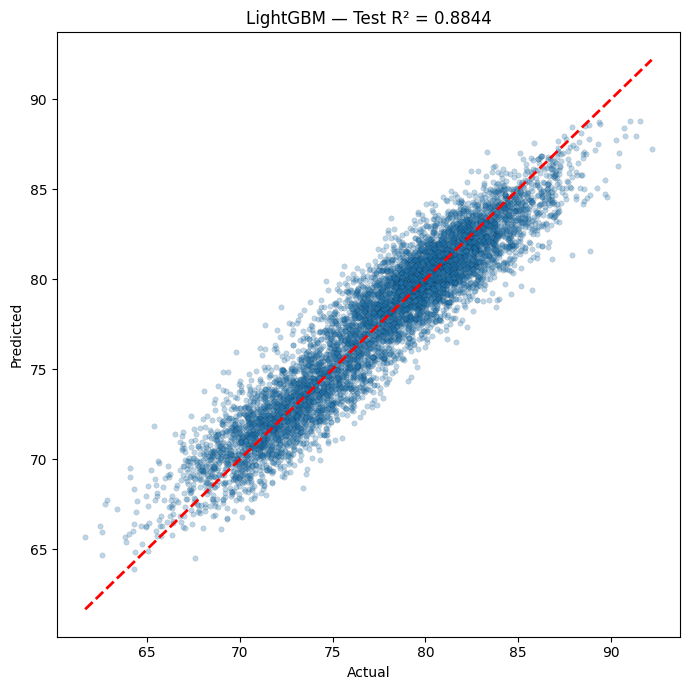

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, best["y_test_pred"], alpha=0.3, s=15, edgecolor="k", linewidth=0.2)
lims = [min(y_test.min(), best["y_test_pred"].min()),
        max(y_test.max(), best["y_test_pred"].max())]
ax.plot(lims, lims, "r--", linewidth=2)

ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"{best_name} — Test R² = {best['test']['r2']:.4f}")
plt.tight_layout()
plt.show()